In [1]:
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
import sys
sys.path.append('../../pybeh')
sys.path.append('../../CourierReinstate1')
import cmlreaders as cml
from cmldask import CMLDask as da
from dask.distributed import wait, as_completed
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.colors as mcolors
import seaborn as sns
import pandas as pd
import xarray as xr
import pandas_to_pybeh as pb
import scipy as scp
import re
import math
import pickle
import gc
from scipy import stats
from ptsa.data.filters import ButterworthFilter, MorletWaveletFilter
from statsmodels.stats.multitest import multipletests
from compute_scalp_features import create_baseline_events
from BehavioralFunctions import *

pd.options.display.max_rows = 100
pd.options.display.max_columns = 50
%matplotlib inline
import importlib
import statsmodels.api as sm
from statsmodels.stats.anova import AnovaRM

In [2]:
subjects = ['LTP606', 'LTP607', 'LTP609', 'LTP610', 'LTP612']
# subjects = ['LTP606']
experiment = 'ValueCourier'

### Encoding

In [3]:
REL_START, REL_STOP = 200, 3000
BUFFER_MS = 1000
WIDTH = 6

FREQS = np.logspace(np.log10(2), np.log10(100), 46)
NOTCH_BAND = (58., 62.)
BATCH_EVENTS = 64
ROI_ORDER = ['LAI','RAI','LAS','RAS','LPS','RPS','LPI','RPI']

def assign_roi(channel):
    roi_dict = {
        'LAS':['C24','C25','D2','D3','D4','D11','D12','D13'],
        'LAI':['C31','C32','D5','D6','D9','D10','D21','D22'],
        'LPS':['D29','A5','A6','A7','A8','A17','A18'],
        'LPI':['D30','D31','A9','A10','A11','A15','A16'],
        'RAS':['B30','B31','B32','C2','C3','C4','C11','C12'],
        'RAI':['B24','B25','B28','B29','C5','C6','C9','C10'],
        'RPS':['A30','A31','A32','B3','B4','B5','B13'],
        'RPI':['A28','A29','B6','B7','B8','B11','B12'],
    }
    for roi, chans in roi_dict.items():
        if channel in chans:
            return roi
    return None

In [4]:
df_idx = cml.get_data_index('ltp').query("experiment == 'ValueCourier'").copy()
if subjects is not None:
    df_idx = df_idx[df_idx['subject'].isin(subjects)]
subjects = sorted(df_idx.subject.unique())

In [5]:
def welch_t_from_agg(n1, sum1, sumsq1, n0, sum0, sumsq0):
    with np.errstate(divide='ignore', invalid='ignore'):
        m1 = sum1 / np.maximum(n1, 1)
        m0 = sum0 / np.maximum(n0, 1)
        v1 = (sumsq1 - (sum1**2)/np.maximum(n1, 1)) / np.maximum(n1 - 1, 1)
        v0 = (sumsq0 - (sum0**2)/np.maximum(n0, 1)) / np.maximum(n0 - 1, 1)
        denom = np.sqrt(v1 / np.maximum(n1, 1) + v0 / np.maximum(n0, 1))
        t = (m1 - m0) / denom
        t[~np.isfinite(t)] = np.nan
    return t

In [6]:
def process_subject_stats(subject, exp, batch):
    sessions = cml.get_data_index('ltp').query(
        "experiment == @exp and subject == @subject"
    ).session.unique()

    n1, n0 = {}, {}
    sum1, sum0 = {}, {}
    sumsq1, sumsq0 = {}, {}
    freq_vec = FREQS

    for sess in sessions:
        ret_evs = None
        delib_evs = None
        try:
            reader = cml.CMLReader(subject=subject, experiment=exp, session=sess)
            evs_all = reader.load('task_events')
            evs_all = evs_all[(evs_all['type']=='WORD') & (evs_all['eegoffset']>=0)]
            print(evs_all)
            if evs_all.empty:
                continue

            for start in range(0, len(evs_all), batch):
                evs = evs_all.iloc[start:start+batch]
                rec_mask = evs['recalled'].to_numpy().astype(bool)

                # eeg = reader.load_eeg(
                #     evs, rel_start=-BUFFER_MS, rel_stop=REL_STOP + BUFFER_MS, clean='LCF'
                # ).to_ptsa()
                eeg = reader.load_eeg(
                    evs, rel_start=-BUFFER_MS, rel_stop=REL_STOP + BUFFER_MS
                ).to_ptsa()

                eeg = ButterworthFilter(freq_range=list(NOTCH_BAND), filt_type='stop', order=4).filter(eeg)
                mw = MorletWaveletFilter(freqs=freq_vec, width=WIDTH, output='power', complete=True)
                pwr = mw.filter(eeg).sel(time=slice(REL_START, REL_STOP)).mean(dim='time')

                p = pwr.transpose('event', 'channel', 'frequency').values
                chans = pwr['channel'].values

                for ci, ch in enumerate(chans):
                    if ch not in n1:
                        z = np.zeros(len(freq_vec), dtype=np.float64)
                        n1[ch] = 0; n0[ch] = 0
                        sum1[ch] = z.copy(); sum0[ch] = z.copy()
                        sumsq1[ch] = z.copy(); sumsq0[ch] = z.copy()

                if rec_mask.any():
                    vals = p[rec_mask]
                    s = vals.sum(axis=0)
                    ss = (vals**2).sum(axis=0)
                    cnt = rec_mask.sum()
                    for ci, ch in enumerate(chans):
                        sum1[ch]   += s[ci]
                        sumsq1[ch] += ss[ci]
                        n1[ch]     += cnt

                nrec_mask = ~rec_mask
                if nrec_mask.any():
                    vals = p[nrec_mask]
                    s = vals.sum(axis=0)
                    ss = (vals**2).sum(axis=0)
                    cnt = nrec_mask.sum()
                    for ci, ch in enumerate(chans):
                        sum0[ch]   += s[ci]
                        sumsq0[ch] += ss[ci]
                        n0[ch]     += cnt

                del eeg, pwr, p
                gc.collect()

        except Exception as e:
            print(f"[WARN] {subject} session {sess} skipped: {e}")
            continue

    if not n1:
        return pd.DataFrame(columns=['subject','channel','frequency','t'])

    chans_sorted = sorted(n1.keys())
    C, F = len(chans_sorted), len(freq_vec)

    N1  = np.zeros((C, F));  N0  = np.zeros((C, F))
    S1  = np.zeros((C, F));  S0  = np.zeros((C, F))
    SS1 = np.zeros((C, F));  SS0 = np.zeros((C, F))

    for i, ch in enumerate(chans_sorted):
        N1[i,:]  = n1[ch];   N0[i,:]  = n0[ch]
        S1[i,:]  = sum1[ch]; S0[i,:]  = sum0[ch]
        SS1[i,:] = sumsq1[ch]; SS0[i,:] = sumsq0[ch]

    t_cf = welch_t_from_agg(N1, S1, SS1, N0, S0, SS0)

    df = (pd.DataFrame(
            t_cf.reshape(-1),
            index=pd.MultiIndex.from_product([chans_sorted, freq_vec], names=['channel','frequency']),
            columns=['t']
         ).reset_index())
    df['subject'] = subject
    return df

In [7]:
client = da.new_dask_client_slurm(
    job_name="encoding",
    memory_per_job="80GB",
    max_n_jobs=10,
    queue="RAM",
    local_directory="~/scratch",
    log_directory="log_directory"
)

Unique port for zrentala is 51618
{'dashboard_address': ':51618'}
To view the dashboard, run: 
`ssh -fN zrentala@rhino2.psych.upenn.edu -L 8000:192.168.86.140:33914` in your local computer's terminal (NOT rhino) 
and then navigate to localhost:8000 in your browser


In [8]:
subjects = ['LTP606']
futures = [client.submit(process_subject_stats, s, experiment, BATCH_EVENTS) for s in subjects]

In [9]:
subj_chan_t_list, n_done, n_fail = [], 0, 0
for fut in as_completed(futures):
    try:
        df_sub = fut.result()
        subj_chan_t_list.append(df_sub)
        n_done += 1
        sub = df_sub['subject'].iat[0] if not df_sub.empty else 'EMPTY_SUBJECT'
        print(f"[DONE] {n_done}/{len(subjects)} :: {sub} (rows={len(df_sub)})")
    except Exception as e:
        n_fail += 1
        print(f"[ERR] Future failed ({n_fail} fails): {e}")

[DONE] 1/1 :: LTP606 (rows=6302)


In [10]:
client.shutdown()

2026-01-23 11:49:37,075 - distributed.deploy.adaptive_core - INFO - Adaptive stop


In [11]:
chan_t_all = (pd.concat(subj_chan_t_list, ignore_index=True)
              if subj_chan_t_list else
              pd.DataFrame(columns=['subject','channel','frequency','t']))
chan_t_all['ROI'] = chan_t_all['channel'].map(assign_roi)
chan_t_all = chan_t_all.dropna(subset=['ROI']).copy()

subj_roi_t = (chan_t_all.groupby(['subject','ROI','frequency'], as_index=False)['t'].mean())

In [12]:
def one_samp(s):
    s = s.dropna()
    if s.empty: return pd.Series({'t_mean':np.nan,'p':np.nan})
    t_mean = s.mean()
    _, p = stats.ttest_1samp(s, 0.0, nan_policy='omit')
    return pd.Series({'t_mean':t_mean, 'p':p})

In [13]:
mean_tbl = (subj_roi_t
            .groupby(['ROI','frequency'], as_index=False)['t']
            .mean()
            .rename(columns={'t': 't_mean'}))

p_tbl_long = (subj_roi_t
              .groupby(['ROI','frequency'])['t']
              .apply(lambda s: stats.ttest_1samp(s.dropna(), 0.0)[1]
                     if s.notna().any() else np.nan)
              .reset_index(name='p'))

agg = mean_tbl.merge(p_tbl_long, on=['ROI','frequency'], how='outer')

heat = agg.pivot(index='frequency', columns='ROI', values='t_mean')
cols_present = [c for c in ROI_ORDER if c in heat.columns]
if cols_present:
    heat = heat[cols_present]

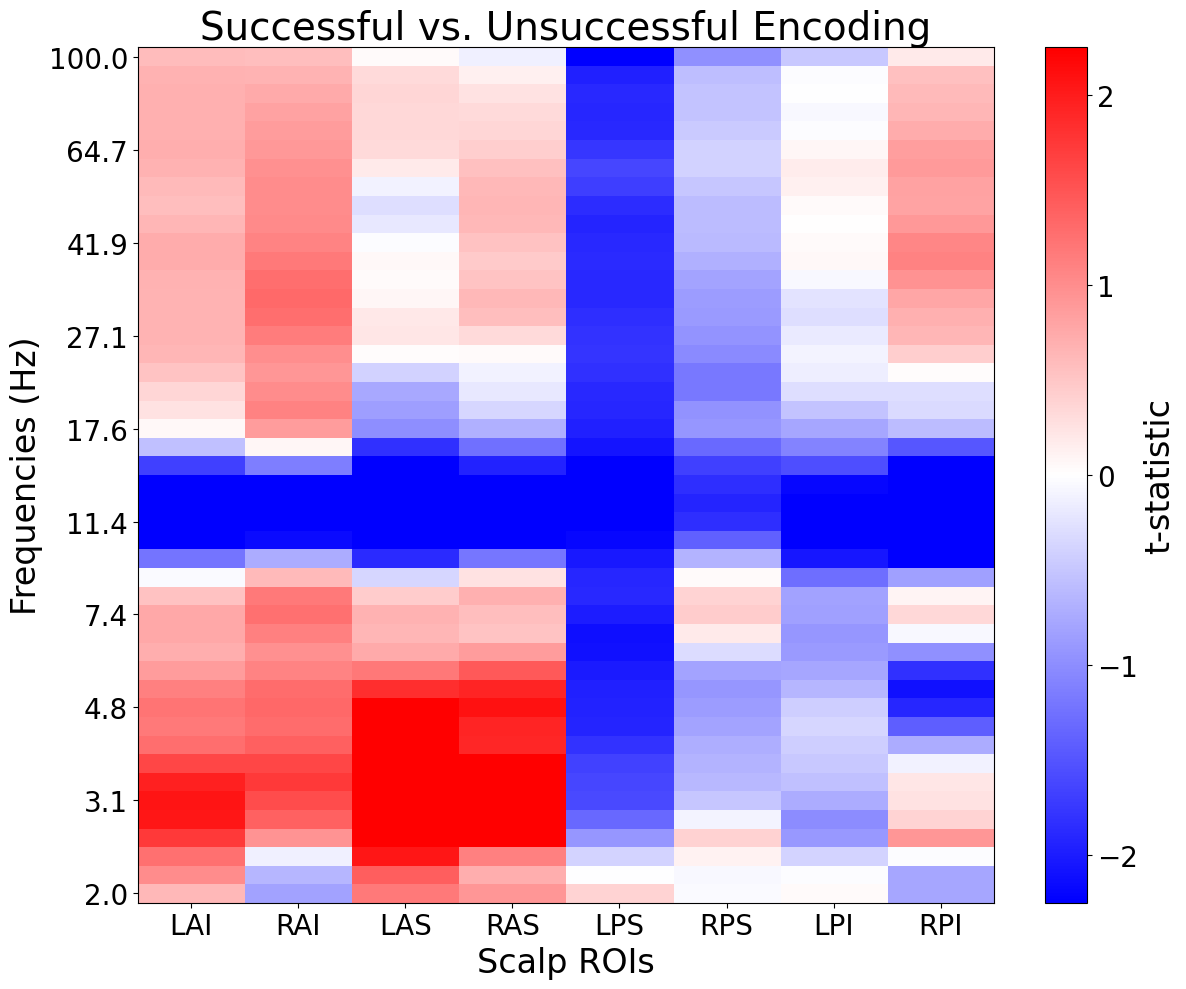

In [14]:
fig = plt.figure(figsize=(12, 10))
ax = plt.gca()
norm = mcolors.TwoSlopeNorm(vmin=-2.25, vcenter=0.0, vmax=2.25)
im = ax.imshow(heat, cmap='bwr', aspect='auto', norm=norm)

freqs = heat.index.values
tick_idx = np.unique(np.round(np.linspace(0, len(freqs)-1, 10)).astype(int))
ax.set_yticks(tick_idx)
ax.set_yticklabels([f'{freqs[i]:.1f}' for i in tick_idx], fontsize=20)

ax.set_xticks(range(heat.shape[1]))
ax.set_xticklabels(list(heat.columns), fontsize=20)

ax.set_xlabel('Scalp ROIs', fontsize=24)
ax.set_ylabel('Frequencies (Hz)', fontsize=24)
ax.set_title('Successful vs. Unsuccessful Encoding', fontsize=28)

cbar = plt.colorbar(im, ax=ax, fraction=.1)
cbar.set_label('t-statistic', size=24)
cbar.set_ticks([-2, -1, 0, 1, 2])
cbar.ax.tick_params(labelsize=20)

ax.invert_yaxis()
ax.grid(False)
plt.tight_layout()
plt.show()